<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-05-21 03:41:18--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  11.2MB/s    in 23s     

2026-05-21 03:41:42 (8.94 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]


#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [35]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [36]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [37]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


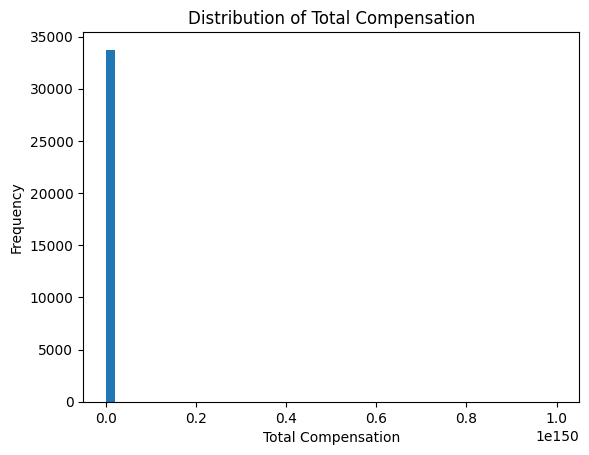

In [38]:
## Write your code here
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""
df_comp = pd.read_sql_query(QUERY, conn)
df_comp = df_comp[df_comp['CompTotal'] < 5e6]

plt.figure()
plt.hist(df_comp['CompTotal'], bins=50)
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.title('Distribution of Total Compensation')
plt.tight_layout()
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


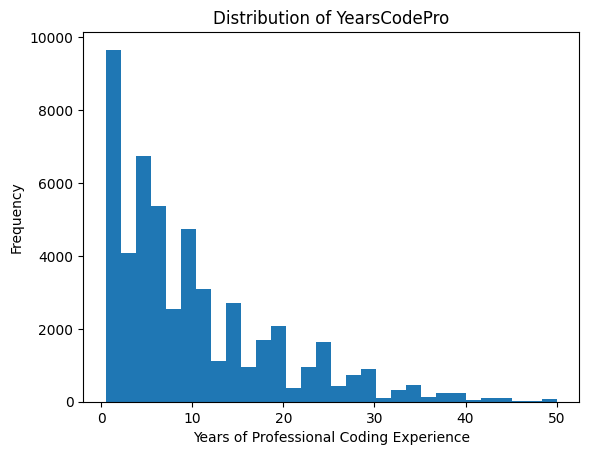

In [39]:
QUERY = """
SELECT YearsCodePro
FROM main
WHERE YearsCodePro IS NOT NULL
"""
df_exp = pd.read_sql_query(QUERY, conn)

df_exp['YearsCodePro'] = df_exp['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 50
})
df_exp['YearsCodePro'] = pd.to_numeric(df_exp['YearsCodePro'], errors='coerce')

plt.figure()
plt.hist(df_exp['YearsCodePro'], bins=30)
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Frequency')
plt.title('Distribution of YearsCodePro')
plt.tight_layout()
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


After cleaning: (0, 2)
AgeGroup
<25      0
25-34    0
35-49    0
50+      0
Name: count, dtype: int64


/tmp/ipykernel_300/2433418300.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


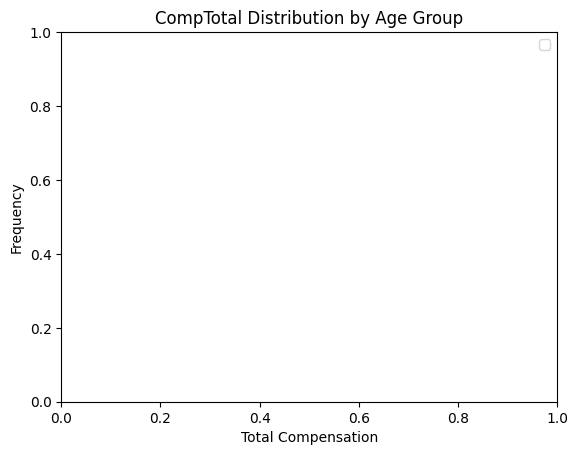

In [40]:
QUERY = """
SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL AND Age IS NOT NULL
"""
df_rel = pd.read_sql_query(QUERY, conn)
df_rel['CompTotal'] = pd.to_numeric(df_rel['CompTotal'], errors='coerce')
df_rel = df_rel.dropna(subset=['CompTotal'])
df_rel = df_rel[df_rel['CompTotal'] < 5e6]

age_order = ['Under 18', '18-24 years old', '25-34 years old', '35-44 years old',
             '45-54 years old', '55-64 years old', '65 years or older']
age_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_rel['AgeGroup'] = df_rel['Age'].map(dict(zip(age_order, age_labels)))
df_rel = df_rel.dropna(subset=['AgeGroup'])

print(df_rel['AgeGroup'].value_counts())

plt.figure()
for lbl in age_labels:
    subset = df_rel[df_rel['AgeGroup'] == lbl]
    if len(subset) > 0:
        plt.hist(subset['CompTotal'], bins=40, alpha=0.5, label=lbl)
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.title('CompTotal Distribution by Age Group')
plt.legend()
plt.tight_layout()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**



Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


Sample TimeSearching values: <ArrowStringArray>
[       '30-60 minutes a day',       '60-120 minutes a day',
        '15-30 minutes a day', 'Less than 15 minutes a day',
     'Over 120 minutes a day']
Length: 5, dtype: str
Age                         18-24 years old  25-34 years old  35-44 years old  \
TimeSearching                                                                   
15-30 minutes a day                     922             3332             2275   
30-60 minutes a day                    1614             4901             2924   
60-120 minutes a day                    996             2345             1309   
Less than 15 minutes a day              223             1047              910   
Over 120 minutes a day                  420              978              542   

Age                         45-54 years old  55-64 years old  \
TimeSearching                                                  
15-30 minutes a day                     888              325   
30-60 minutes a d

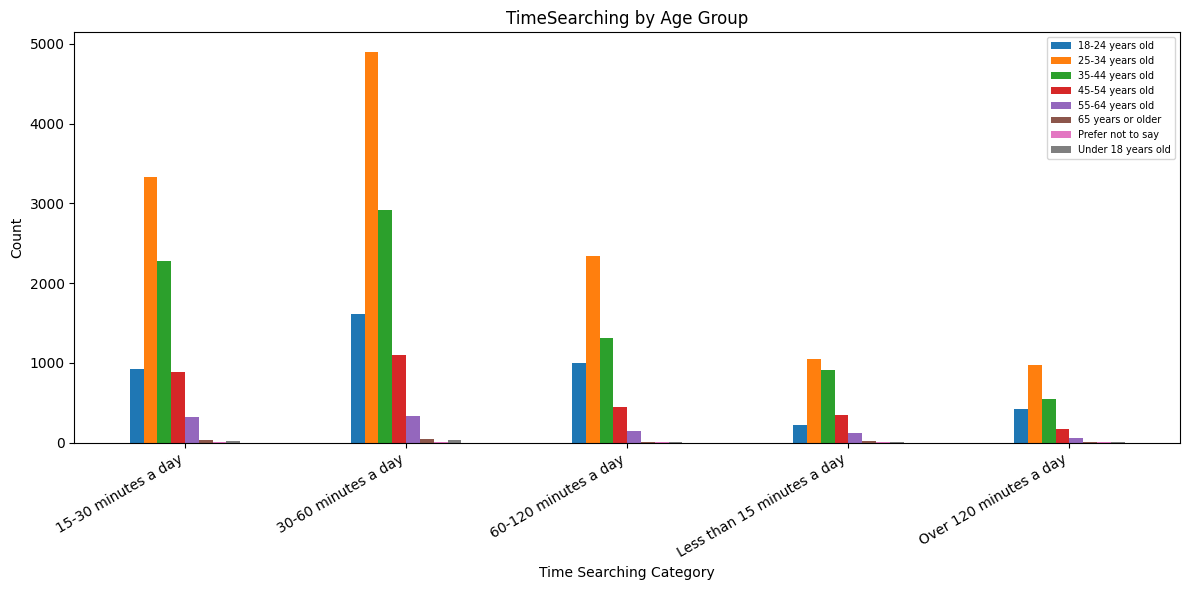

In [7]:
QUERY = """
SELECT TimeSearching, Age
FROM main
WHERE TimeSearching IS NOT NULL AND Age IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

print("Sample TimeSearching values:", df['TimeSearching'].unique()[:5])

# TimeSearching is categorical — use crosstab
pivot = pd.crosstab(df['TimeSearching'], df['Age'])
print(pivot.head())

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax)
ax.set_xlabel('Time Searching Category')
ax.set_ylabel('Count')
ax.set_title('TimeSearching by Age Group')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


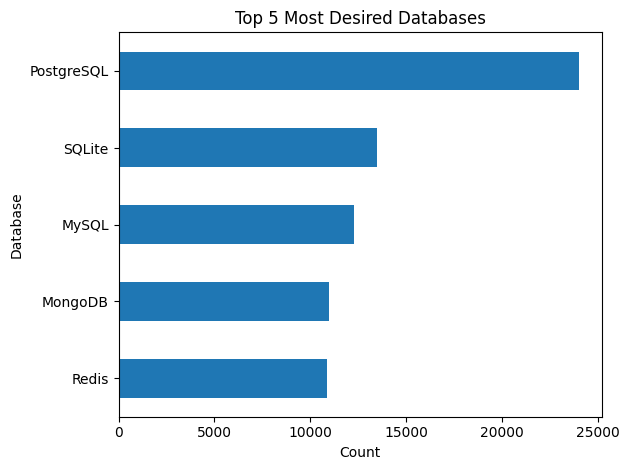

In [42]:
QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
df['DatabaseWantToWorkWith'] = df['DatabaseWantToWorkWith'].str.split(';')
df = df.explode('DatabaseWantToWorkWith')
df['DatabaseWantToWorkWith'] = df['DatabaseWantToWorkWith'].str.strip()

top5 = df['DatabaseWantToWorkWith'].value_counts().head(5)
print(top5)

plt.figure()
top5.sort_values().plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Database')
plt.title('Top 5 Most Desired Databases')
plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64


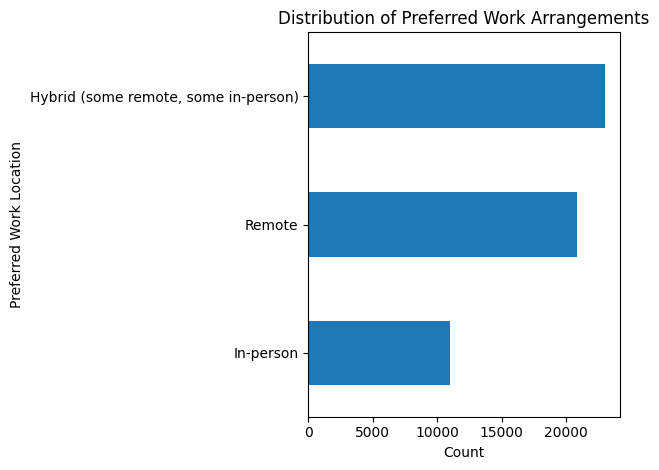

In [43]:
QUERY = """
SELECT RemoteWork
FROM main
WHERE RemoteWork IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
counts = df['RemoteWork'].value_counts()
print(counts)

plt.figure()
counts.sort_values().plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Preferred Work Location')
plt.title('Distribution of Preferred Work Arrangements')
plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


(0, 2)


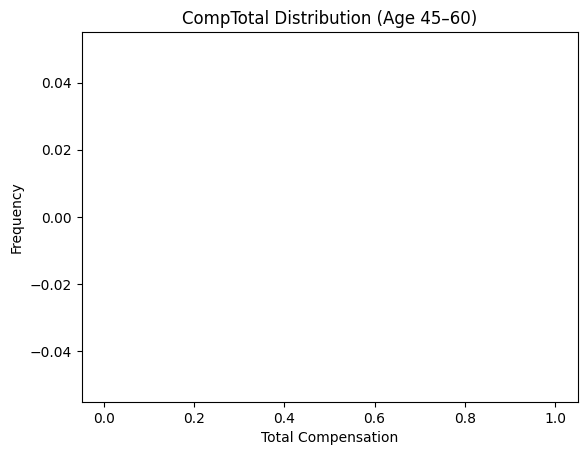

In [44]:
QUERY = """
SELECT CompTotal, Age
FROM main
WHERE CompTotal IS NOT NULL AND Age IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df.dropna(subset=['CompTotal'])

df_filtered = df[df['Age'].isin(['45-54 years old', '55-64 years old'])]
df_filtered = df_filtered[df_filtered['CompTotal'] < 5e6]

print(f"Records (age 45-60): {df_filtered.shape[0]}")

plt.figure()
plt.hist(df_filtered['CompTotal'], bins=50)
plt.xlabel('Total Compensation')
plt.ylabel('Frequency')
plt.title('CompTotal Distribution (Age 45–60)')
plt.tight_layout()
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


(28356, 2)
ExpGroup
0-5      10249
6-10      7737
11-20     6899
20+       3471
Name: count, dtype: int64


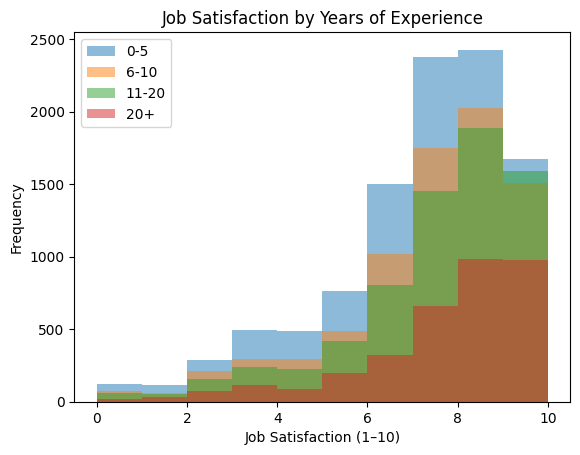

In [45]:
QUERY = """
SELECT JobSat, YearsCodePro
FROM main
WHERE JobSat IS NOT NULL AND YearsCodePro IS NOT NULL
"""
df = pd.read_sql_query(QUERY, conn)

df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')
df['YearsCodePro'] = df['YearsCodePro'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 50
})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df = df.dropna(subset=['JobSat', 'YearsCodePro'])

print(f"Records: {df.shape}")

bins = [0, 5, 10, 20, 50]
labels = ['0-5', '6-10', '11-20', '20+']
df['ExpGroup'] = pd.cut(df['YearsCodePro'], bins=bins, labels=labels)
print(df['ExpGroup'].value_counts())

plt.figure()
for group in labels:
    subset = df[df['ExpGroup'] == group]
    if len(subset) > 0:
        plt.hist(subset['JobSat'], bins=10, alpha=0.5, label=group)
plt.xlabel('Job Satisfaction (1–10)')
plt.ylabel('Frequency')
plt.title('Job Satisfaction by Years of Experience')
plt.legend()
plt.tight_layout()
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [46]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
